In [1]:
import numpy as np
import matplotlib.pyplot as plt
import uproot
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 150 # Larger Plots
import mplhep as hep # Package for nice layouts
hep.style.use("ATLAS") # Be a rebel

ModuleNotFoundError: No module named 'uproot'

In [2]:
#Define files, names and colors to use
files = [
    "data.root", "qcd.root", "wjets.root", "single_top.root", "ww.root", "ttbar.root",  "wz.root", "zz.root", "dy.root"
]
names = [
    "Data", "QCD", "WJets", "Single Top", "WW", "TTbar", "WZ", "ZZ",  "DY" 
]
colors = {
    "Data":"k", "QCD":"violet", "WJets":"lime", "Single Top":"royalblue", "WW":"rebeccapurple", "TTbar":"r", "WZ":"cyan", "ZZ":"yellowgreen",  "DY":"gold" 
}
    
#Load files and store them in the data dict
data_paths = {name:f"./Data/{files[i]}:events" for i,name in enumerate(names)}
data = {}
for name in names:
    with uproot.open(data_paths[name]) as f:
        data[name] = f.arrays()

        #Print Tree content for one tree
        if name == "TTbar":
            print(f.show())

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
NJet                 | int32_t                  | AsDtype('>i4')
Jet_Px               | float[]                  | AsJagged(AsDtype('>f4'))
Jet_Py               | float[]                  | AsJagged(AsDtype('>f4'))
Jet_Pz               | float[]                  | AsJagged(AsDtype('>f4'))
Jet_E                | float[]                  | AsJagged(AsDtype('>f4'))
Jet_btag             | float[]                  | AsJagged(AsDtype('>f4'))
Jet_ID               | bool[]                   | AsJagged(AsDtype('bool'))
NMuon                | int32_t                  | AsDtype('>i4')
Muon_Px              | float[]                  | AsJagged(AsDtype('>f4'))
Muon_Py              | float[]                  | AsJagged(AsDtype('>f4'))
Muon_Pz              | float[]                  | AsJagged(AsDtype('>f4'))
Muon_E               | float[]  

In [3]:
# Calculate and or get different values
def getVar(data, var_name):
    if var_name in data.fields:
        return data[var_name]
    # Get the number of particles that fulfill the BTag cut
    if var_name == "NBJet":
        return np.sum(data["Jet_btag"] > 1.74, axis = 1)
    # Get muon PT
    if var_name == "Muon_Pt":
        return np.sqrt(data["Muon_Px"][:,0]**2 + data["Muon_Py"][:,0]**2)
    # Get MET
    if var_name == "MET":
        return np.sqrt(data["MET_px"]**2 + data["MET_py"]**2)

    # Get center of mass for qq or qqb system
    if "M_qq" in var_name:
        # Find out with particles are b jets
        is_BJet = data["Jet_btag"] > 1.74
        # Get center of mass for qq system (no b jets)
        if var_name == "M_qq":
            cut = ~is_BJet
            return np.sqrt(
                (  data["Jet_E"] [~is_BJet][:,0] + data["Jet_E"] [~is_BJet][:,1])**2
                - (data["Jet_Px"][~is_BJet][:,0] + data["Jet_Px"][~is_BJet][:,1])**2
                - (data["Jet_Py"][~is_BJet][:,0] + data["Jet_Py"][~is_BJet][:,1])**2
                - (data["Jet_Pz"][~is_BJet][:,0] + data["Jet_Pz"][~is_BJet][:,1])**2
            )
        # Get center of mass for qqb system. The number i in qqbi specifies if you use the leading (i==1) or subleading (i==2) b quark
        if var_name in ["M_qqb1", "M_qqb2"]:
            b = int(var_name[-1]) - 1
            return np.sqrt(
                (  data["Jet_E"] [~is_BJet][:,0] + data["Jet_E"] [~is_BJet][:,1] + data["Jet_E"] [is_BJet][:,b])**2
                - (data["Jet_Px"][~is_BJet][:,0] + data["Jet_Px"][~is_BJet][:,1] + data["Jet_Px"][is_BJet][:,b])**2
                - (data["Jet_Py"][~is_BJet][:,0] + data["Jet_Py"][~is_BJet][:,1] + data["Jet_Py"][is_BJet][:,b])**2
                - (data["Jet_Pz"][~is_BJet][:,0] + data["Jet_Pz"][~is_BJet][:,1] + data["Jet_Pz"][is_BJet][:,b])**2
            )
            
        
        
    raise Exception(f"Unknown Var_Name: {var_name}") 


# Define all the cuts to make and print how they reduce the number of events
def getData(data, cut_NJet = True, cut_NMuon = True, cut_MuonTrigger = True, cut_NBJet = True, cut_MuonPt = True):
    print("Original:     ", len(data))
    if cut_NJet:
        cut = (data["NJet"] >= 4)
        data = data[cut]
    
        print("NJet:         ", len(data))
    
    if cut_NMuon:
        cut = (data["NMuon"] == 1)
        data = data[cut]
    
        print("NMuon:        ", len(data))
    
    if cut_MuonTrigger:
        cut = data["triggerIsoMu24"]
        data = data[cut]

        print("Muon Trigger: ", len(data))
    
    if cut_NBJet:
        NBJet = getVar(data, "NBJet")
        cut = NBJet == 2
    
        data = data[cut]
        print("NBJet:        ", len(data))

        
    if cut_MuonPt:
        muon_pt = getVar(data, "Muon_Pt")
    
        cut = muon_pt >= 25
        data = data[cut]
        print("Muon Pt:      ", len(data))
    print("Final:        ", len(data))
    
    return data

def getCuts(what):
    # Define the cuts used for plotting different quantities
    cut = {"cut_NJet":  True, "cut_NMuon": True, "cut_MuonTrigger": True, "cut_NBJet":  True, "cut_MuonPt": True}
    if what == "NJet":
        cut["cut_NJet"] = False
        cut["cut_NBJet"] = False
        return cut
    if what == "Muon_Pt":
        cut["cut_MuonPt"] = False
        return cut
    if what == "NBJet":
        cut["cut_NBJet"] = False
        return cut
    if what == "MET":
        return cut
    return cut

In [4]:
def getBins(what):
    # Define the binning for different quantities
    
    if "M_" in what or what == "MET":
        start, stop, step = 0, 400, 10
        
    elif what == "NJet" or what == "NBJet":
        start, stop, step = 0, 5, 1
        if what == "NJet":
            start, stop, step = 0, 10, 1

    elif what == "Muon_Pt":
        start, stop, step = 0, 100, 5
        
    
    bins = np.linspace(start, stop, int((stop - start) / step) + 1)
    bin_centers = (bins[1:] + bins[:-1]) / 2
    bin_width = (bins[1:] - bins[:-1])
    return bins, bin_centers, bin_width

#Constants
W_mass = 80.377
t_mass = 172.76

Plotting M_qq
Processing Data
Original:      469384
NJet:          1037
NMuon:         553
Muon Trigger:  553
NBJet:         100
Muon Pt:       96
Final:         96
91.0

Processing QCD
Original:      142
NJet:          28
NMuon:         3
Muon Trigger:  3
NBJet:         0
Muon Pt:       0
Final:         0
0.0

Processing WJets
Original:      109737
NJet:          104
NMuon:         80
Muon Trigger:  80
NBJet:         1
Muon Pt:       1
Final:         1
0.7129907011985779

Processing Single Top
Original:      5684
NJet:          422
NMuon:         362
Muon Trigger:  362
NBJet:         80
Muon Pt:       79
Final:         79
4.015132904052734

Processing WW
Original:      4580
NJet:          37
NMuon:         30
Muon Trigger:  30
NBJet:         0
Muon Pt:       0
Final:         0
0.0

Processing TTbar
Original:      36941
NJet:          22664
NMuon:         2072
Muon Trigger:  1405
NBJet:         448
Muon Pt:       433
Final:         433
92.1478271484375

Processing WZ
Original:      336

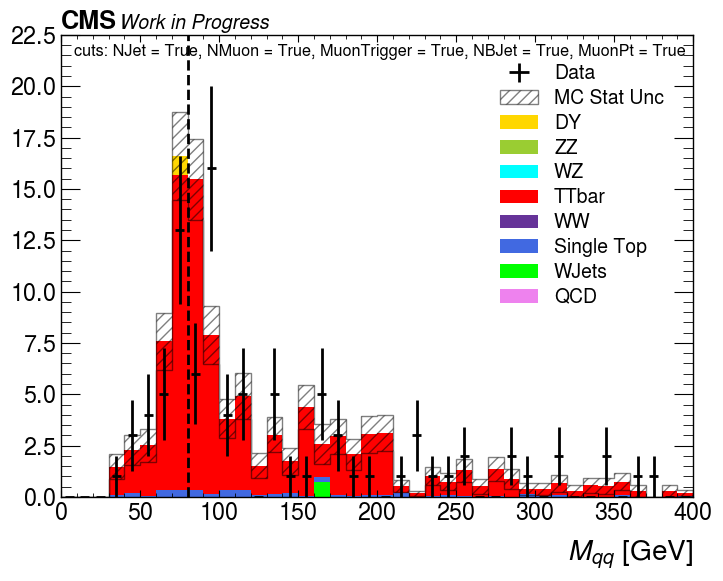

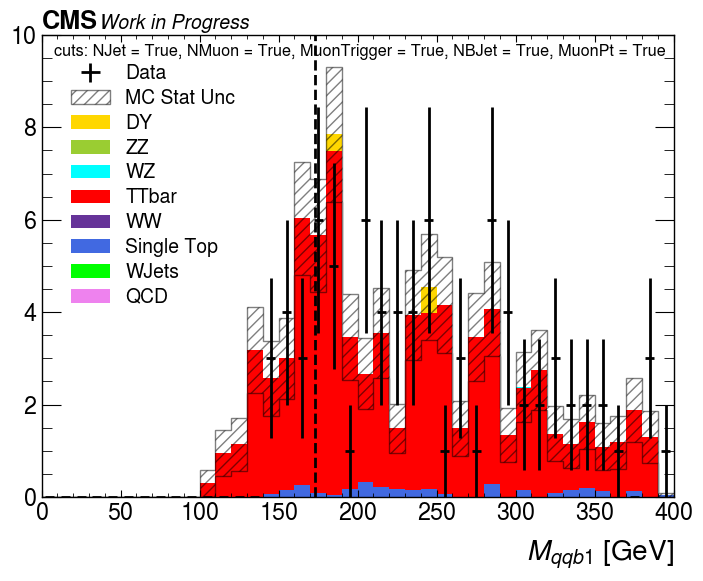

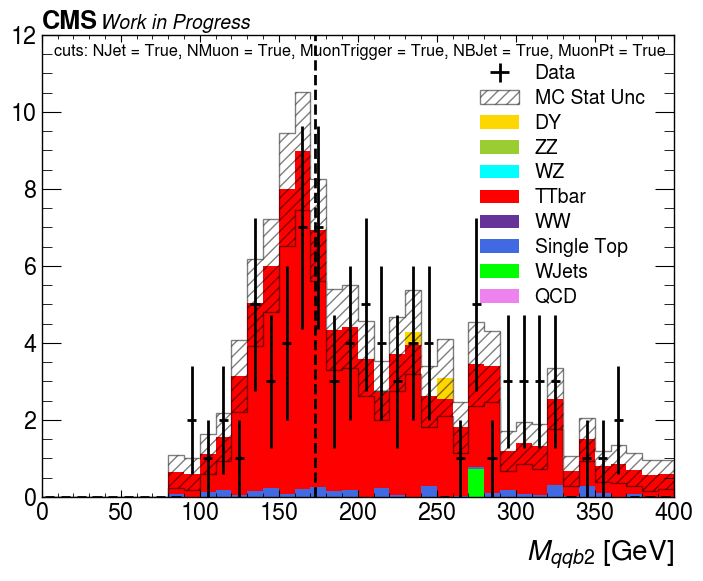

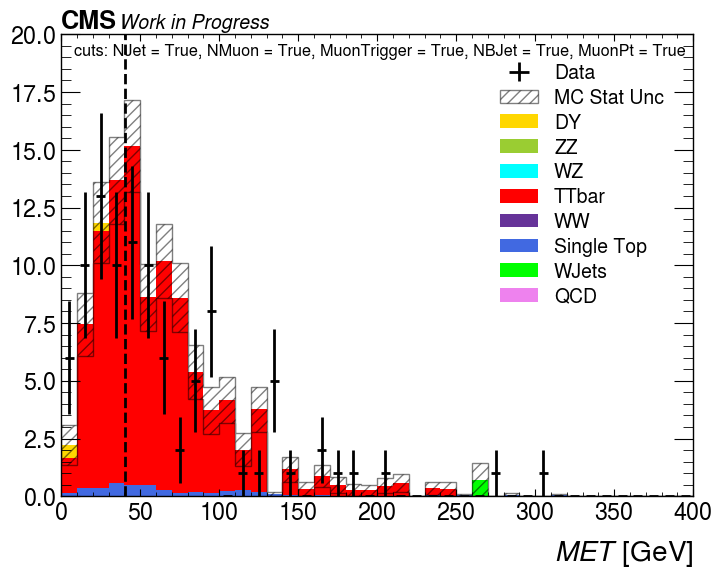

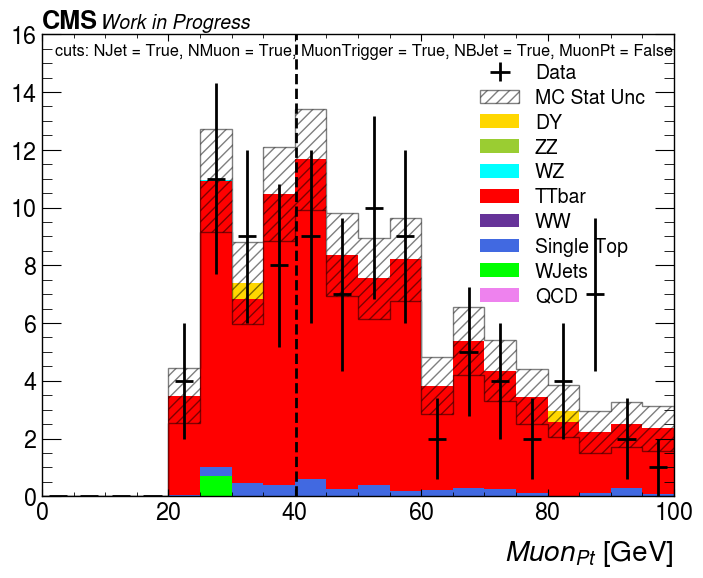

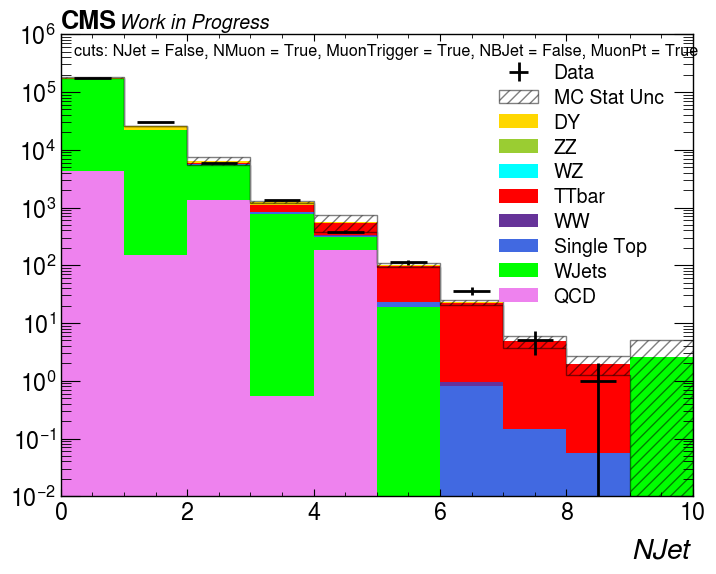

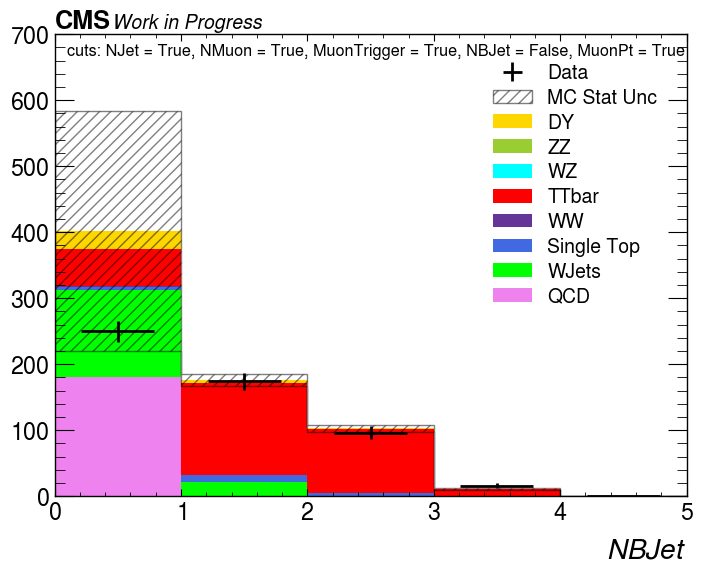

In [5]:
var_names = ["M_qq", "M_qqb1", "M_qqb2", "MET", "Muon_Pt", "NJet", "NBJet"] # The quantities to plot
for var_name in var_names: # Loop through all quantities
    print(f"Plotting {var_name}")
    
    bins, bin_centers, bin_width = getBins(var_name) # Get the binning
    cuts = getCuts(var_name) # Perform the cuts
    
    fig, ax = plt.subplots(1)

    # We want to create a stacked histogram
    baseline = np.zeros(len(bins) - 1)

    # Array to store the variance of the MC histograms (sum of weights squared)
    values_var = np.zeros_like(baseline) 

    for name in names: # Loop through the real data and all MC proccesses that contribute
        print(f"Processing {name}")
        weights = None

        events = getData(data[name], **cuts)

        if name != "Data":
            # Use weights if we look at MC
            weights = getVar(events, "EventWeight")

        var = getVar(events, var_name) # Get the quantitie to plot

        # Create the histogram with our own binning
        values, _ = np.histogram(var, bins = bins, weights = weights)
        
        if name != "Data" and weights is not None:
            # Calculate the variance of the MC proccess (sum of weights squared in each bin)
            values_var_temp, _ = np.histogram(var, bins = bins, weights = weights**2)
            values_var = values_var + values_var_temp
            


        print(np.sum(values))

        if name == "Data":
            # Print the real data with its stat uncert.
            plt.errorbar(bin_centers, values, yerr = np.sqrt(values), xerr = bin_width / np.sqrt(12), linestyle = "", c = colors[name], label = name)
        else:
            # Print the MC as stacked histogram
            plt.stairs(values + baseline, edges=bins, baseline=baseline, fill = True, label = name,color = colors[name])
            baseline = baseline + values
        print()

    #Get the stat uncert. of the MC
    values_err = np.sqrt(values_var)
    #Plot the MC stat uncert. as a shaded area
    plt.stairs(baseline + values_err, edges=bins, baseline=baseline - values_err, fill = False, color = "k", hatch = "///", alpha = 0.5, label = "MC Stat Unc")
    
    # Let's be fancy
    hep.cms.text("Work in Progress", loc = 0)
    
    # Add an explanation of the applied cuts to the plot
    cut_str = "cuts: " + ", ".join([cut.split("_")[-1] +f" = {cuts[cut]}" for cut in cuts])
    
    ax.text(0.02, 0.98, cut_str, transform=ax.transAxes, verticalalignment='top', fontsize="small")
    
    ax.legend(reverse = True)
    split = var_name.split("_")
    
    unit = " [GeV]"

    # Set the corrext axis labels, scales, vetical lines
    if var_name == "M_qq":
        ax.axvline(W_mass, c = "k", linestyle = "--")
    elif "M_qqb" in var_name:
        ax.axvline(t_mass, c = "k", linestyle = "--")
    
    if var_name in ["MET", "Muon_Pt"]:
        ax.axvline(W_mass/2, c = "k", linestyle = "--")
    
    if var_name in ["NJet", "NBJet"]:
        unit = ""
    
    if var_name == "NJet":
        ax.set_yscale("log")
    
    if len(split) == 2:
        ax.set(xlabel="$" + split[0] + "_{" + split[1] + "}$" + unit)
    else:
        ax.set(xlabel="$" + split[0] + "$" + unit)

    # Save the plot as a .svg file
    plt.savefig(f"{var_name}.svg", transparent = True)

Processing Data
Original:      469384
NJet:          1037
NMuon:         553
Muon Trigger:  553
NBJet:         100
Muon Pt:       96
Final:         96
79.0 82.0
79.0
82.0

Processing QCD
Original:      142
NJet:          28
NMuon:         3
Muon Trigger:  3
NBJet:         0
Muon Pt:       0
Final:         0
0.0
0.0

Processing WJets
Original:      109737
NJet:          104
NMuon:         80
Muon Trigger:  80
NBJet:         1
Muon Pt:       1
Final:         1
0.0
0.7129907011985779

Processing Single Top
Original:      5684
NJet:          422
NMuon:         362
Muon Trigger:  362
NBJet:         80
Muon Pt:       79
Final:         79
3.010937210172415
3.6303765773773193

Processing WW
Original:      4580
NJet:          37
NMuon:         30
Muon Trigger:  30
NBJet:         0
Muon Pt:       0
Final:         0
0.0
0.0

Processing TTbar
Original:      36941
NJet:          22664
NMuon:         2072
Muon Trigger:  1405
NBJet:         448
Muon Pt:       433
Final:         433
75.63135528564453


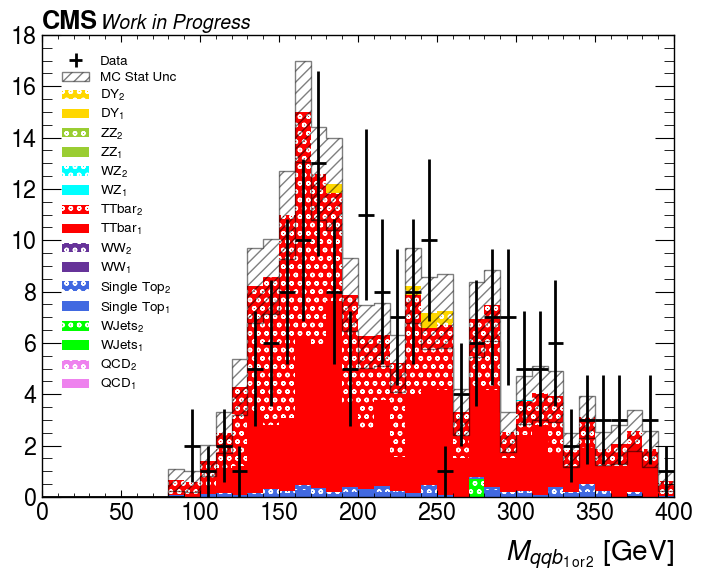

In [6]:
# Same as before, but now we combine the qqb1 and qqb2 values, so we take the combination with both b quarks
bins, bin_centers, bin_width = getBins("M_")
var_names = ["M_qqb1", "M_qqb2"]
fig, ax = plt.subplots(1)

baseline = np.zeros(len(bins) - 1)
values_var = np.zeros_like(baseline)
for name in names:
    print(f"Processing {name}")
    weights = None

    events = getData(data[name])

    if name != "Data":
        weights = getVar(events, "EventWeight")
    
    if name == "Data":
        var1 = getVar(events, var_names[0])
        var2 = getVar(events, var_names[1])


        values1, _ = np.histogram(var1, bins = bins, weights = weights)
        values2, _ = np.histogram(var2, bins = bins, weights = weights)

        print(np.sum(values1), np.sum(values2))
        
        plt.errorbar(bin_centers, values1 + values2, yerr = np.sqrt(values1 + values2), xerr = bin_width / 2, linestyle = "", c = colors[name], label = name)
    for i, var_name in enumerate(var_names):
        
        
        var = getVar(events, var_name)


        values, _ = np.histogram(var, bins = bins, weights = weights)
        if name != "Data" and weights is not None:
            values_var_temp, _ = np.histogram(var, bins = bins, weights = weights**2)
            values_var = values_var + values_var_temp
        
        
        print(np.sum(values))

        if name == "Data":
            pass
        else:
            hatch = None
            if i == 1:
                hatch = "oo"
            plt.stairs(values + baseline, edges=bins, baseline=baseline, fill = True, label = name + f"$_{var_name[-1]}$", hatch = hatch, color = colors[name], edgecolor = "white")
            baseline = baseline + values
        
    print()

values_err = np.sqrt(values_var)
plt.stairs(baseline + values_err, edges=bins, baseline=baseline - values_err, fill = False, color = "k", hatch = "///", alpha = 0.5, label = "MC Stat Unc")

ax.legend(reverse = True, ncols = 1, fontsize = "x-small")

hep.cms.text("Work in Progress", loc = 0)

ax.set(xlabel="$M_{qqb_{1\,\mathrm{or}\, 2}}$ [GeV]");
plt.savefig("M_qqbb.svg", transparent = True)